## Document Classification
Maxfield Raynolds
Data 620
Spring 2026

### Abstract

Using the text of documents to classify them is a valuable algorithmic task. It allows for significant preprocessing and sorting of documents. A classic version of this task is classifying emails as spam or not spam (aka ham). Of course this function frees the receiver of the unnecessary effort of manually sorting useful emails from useless messages.

Of course with any task of this type there are challenges and tradeoffs. Is it better to eliminate all spam, but also have some regular email be labeled as spam? Or is it better to receive some spam to avoid the risk of important email being labeled as spam?

For this analysis, the latter was taken as the perspective of the author. It is easier to handle some spam not being sorted out than it is to have to search for possibly important emails in a spam folder. As a results the metric focused on optimizing was precision, with the goal of minimizing the total number of false classifications.

THe UC-Irvine Machine Learning Repository's Spambase dataset. This dataset is pre-processed so the text has been processed and turned into potentially spam related features.

This document explores the performance of Gaussian Naive Bayes, Logistic Regression, and Decision Tree algorithms in classifying the dataset while working to achieve the dual goals of minimizing False Positives and minimizing the overall misclassification percentage.

Import the spam dataset:

In [2]:
from os import WCONTINUED

import pandas as pd
from matplotlib import cm
from ucimlrepo import fetch_ucirepo

# fetch dataset
spambase = fetch_ucirepo(id=94)

# data
X = spambase.data.features
y = spambase.data.targets
y = y['Class']
# metadata
print(spambase.metadata)

# variable information
print(spambase.variables)

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

A look at the dataset makeup.

In [3]:
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


A look at the columns of the dataset

In [4]:
X.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


Checking the dataset for the amount of spam versus ham:

In [5]:
y.value_counts('Class')

Class
0    0.605955
1    0.394045
Name: proportion, dtype: float64

Import sci-kit learn tools

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Create the train and test sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

### Initial test on all features:

Test Gaussian Naive Bayes, Logistic Regression, and Decision Tree on the full set of features.

In [8]:
gnb = GaussianNB()
nb_probs = gnb.fit(X_train, y_train).predict_proba(X_test)[:,1]
nb_y_pre = (nb_probs >= 0.5).astype(int)
nb_accuracy = accuracy_score(y_test, nb_y_pre)
nb_precision = precision_score(y_test, nb_y_pre)
nb_recall = recall_score(y_test, nb_y_pre)
nb_f1 = f1_score(y_test, nb_y_pre)
nb_cm = confusion_matrix(y_test, nb_y_pre)

print(nb_accuracy)
print(nb_precision)
print(nb_recall)
print(nb_f1)
print(nb_cm)

0.8382193268186754
0.7163561076604554
0.9664804469273743
0.8228299643281808
[[426 137]
 [ 12 346]]


<Axes: >

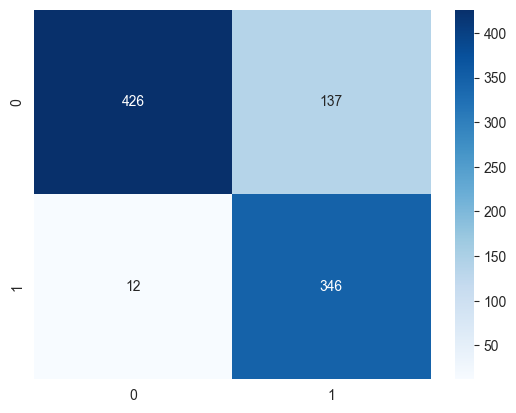

In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.heatmap(nb_cm, annot=True, fmt='g', cmap='Blues')

In [10]:
logreg = LogisticRegression(max_iter=10000)
log_probs = logreg.fit(X_train, y_train).predict_proba(X_test)[:,1]
log_y_pre = (log_probs >= 0.5).astype(int)
log_accuracy = accuracy_score(y_test, log_y_pre)
log_precision = precision_score(y_test, log_y_pre)
log_recall = recall_score(y_test, log_y_pre)
log_f1 = f1_score(y_test, log_y_pre)
log_cm = confusion_matrix(y_test, log_y_pre)
print(log_accuracy)
print(log_precision)
print(log_recall)
print(log_f1)
print(log_cm)

0.9283387622149837
0.9147727272727273
0.8994413407821229
0.9070422535211268
[[533  30]
 [ 36 322]]


<Axes: >

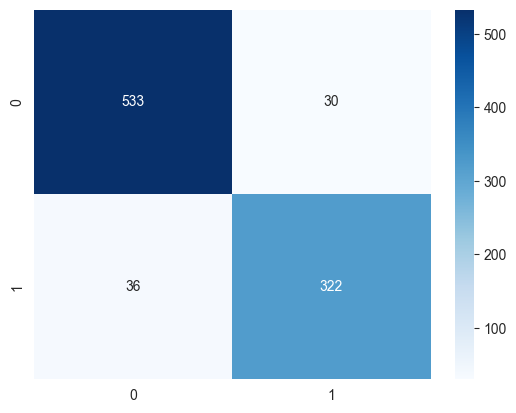

In [11]:
sns.heatmap(log_cm, annot=True, fmt='g', cmap='Blues')

In [12]:
tree = DecisionTreeClassifier()
tree_probs = tree.fit(X_train, y_train).predict_proba(X_test)[:,1]
tree_y_pre = (tree_probs >= 0.5).astype(int)
tree_accuracy = accuracy_score(y_test, tree_y_pre)
tree_precision = precision_score(y_test, tree_y_pre)
tree_recall = recall_score(y_test, tree_y_pre)
tree_f1 = f1_score(y_test, tree_y_pre)
tree_cm = confusion_matrix(y_test, tree_y_pre)
print(tree_accuracy)
print(tree_precision)
print(tree_recall)
print(tree_f1)
print(tree_cm)

0.9022801302931596
0.8661202185792349
0.8854748603351955
0.8756906077348067
[[514  49]
 [ 41 317]]


In [13]:
mis_error = (tree_cm[0,1]+tree_cm[1,0])/np.sum(tree_cm)
mis_error

np.float64(0.09771986970684039)

<Axes: >

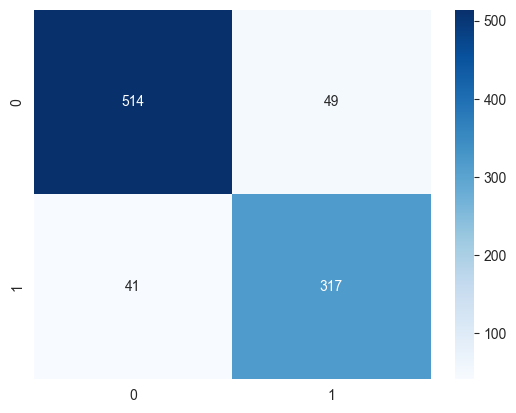

In [14]:
sns.heatmap(tree_cm, annot=True, cmap='Blues', fmt='g')

### Use a function

The following code builds a function to test and compare at different probability thresholds whether a message is spam allowing for inspection of the results all at once.

In [15]:
def model_test(models, X_train, y_train, X_test, y_test, threshold=0.5):
    results = []
    cms = []
    for model in models:
        model_probs = model.fit(X_train, y_train).predict_proba(X_test)[:,1]
        model_y_pre = (model_probs >= threshold).astype(int)
        model_accuracy = accuracy_score(y_test, model_y_pre)
        model_precision = precision_score(y_test, model_y_pre)
        model_recall = recall_score(y_test, model_y_pre)
        model_f1 = f1_score(y_test, model_y_pre)
        model_cm = confusion_matrix(y_test, model_y_pre)

        name = model.__class__.__name__

        results.append({
            'model': name,
            'threshold': threshold,
            'accuracy': model_accuracy,
            'precision': model_precision,
            'recall': model_recall,
            'f1': model_f1,
            'misclassification_error': (model_cm[0,1]+model_cm[1,0])/np.sum(model_cm)
        })

        cms.append(model_cm)

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1,len(cms), figsize=(15,4))

    for i, (cm, ax) in enumerate(zip(cms, axes)):
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=ax)
        ax.set_title(f'{models[i].__class__.__name__} (thr={threshold})')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    return df

In [16]:
models = [GaussianNB(), LogisticRegression(max_iter=10000), DecisionTreeClassifier()]

,model,threshold,accuracy,precision,recall,f1,misclassification_error
1,LogisticRegression,0.5,0.928339,0.914773,0.899441,0.907042,0.071661
4,LogisticRegression,0.6,0.919653,0.935583,0.851955,0.891813,0.080347
2,DecisionTreeClassifier,0.5,0.910966,0.875000,0.899441,0.887052,0.089034
7,LogisticRegression,0.7,0.906623,0.950331,0.801676,0.869697,0.093377
11,DecisionTreeClassifier,0.8,0.904452,0.862903,0.896648,0.879452,0.095548
14,DecisionTreeClassifier,0.9,0.904452,0.868852,0.888268,0.878453,0.095548
8,DecisionTreeClassifier,0.7,0.899023,0.861035,0.882682,0.871724,0.100977
5,DecisionTreeClassifier,0.6,0.893594,0.855191,0.874302,0.864641,0.106406
10,LogisticRegression,0.8,0.887079,0.963504,0.737430,0.835443,0.112921
12,GaussianNB,0.9,0.842562,0.722338,0.966480,0.826762,0.157438


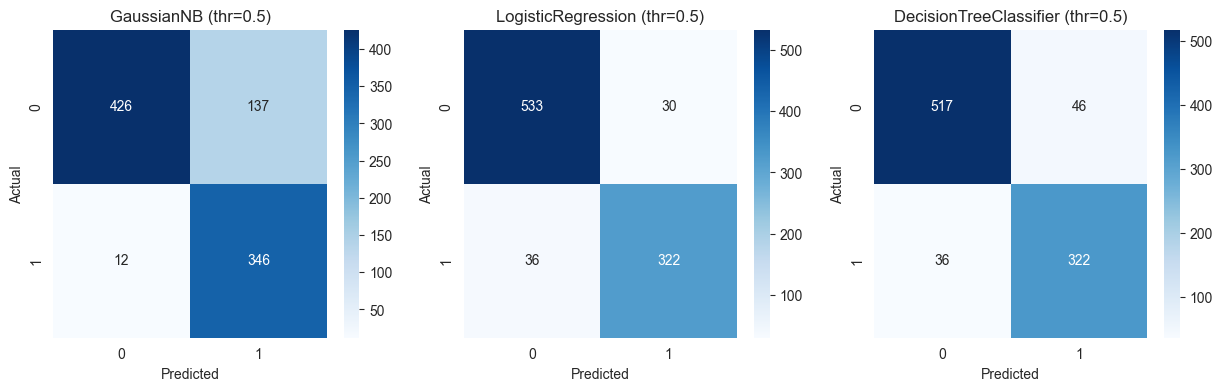

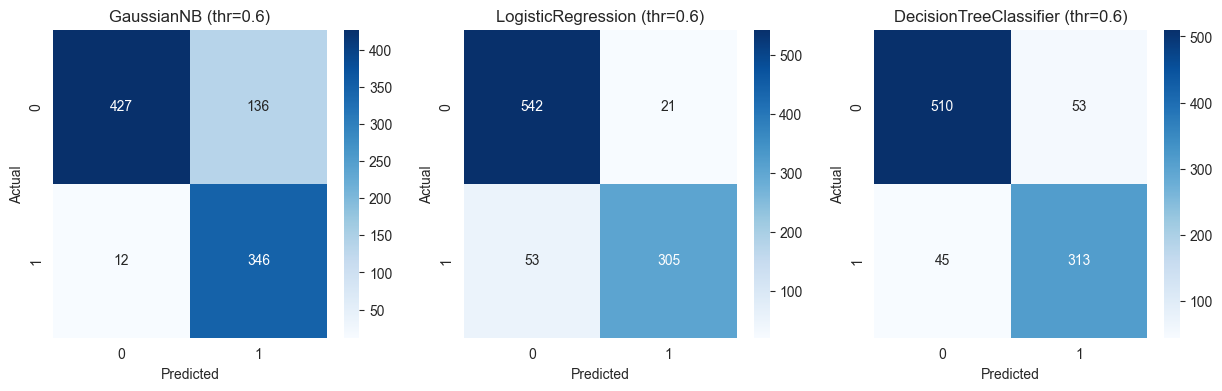

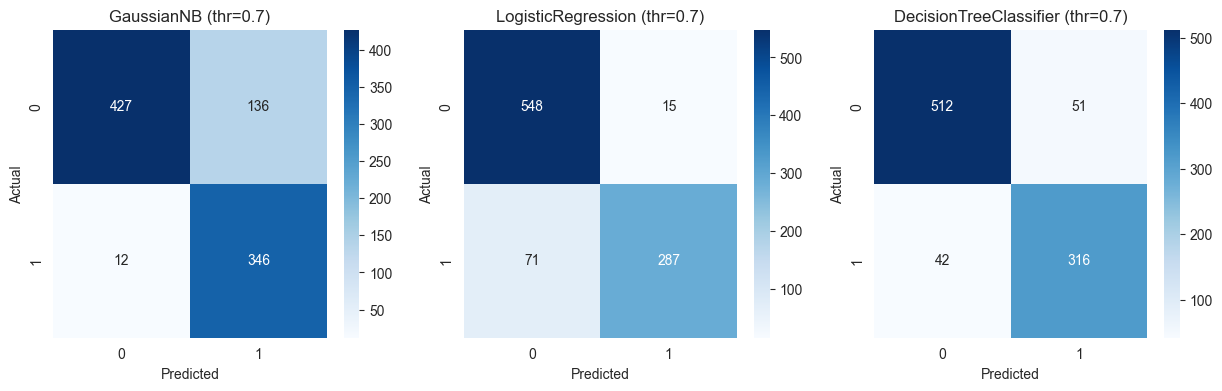

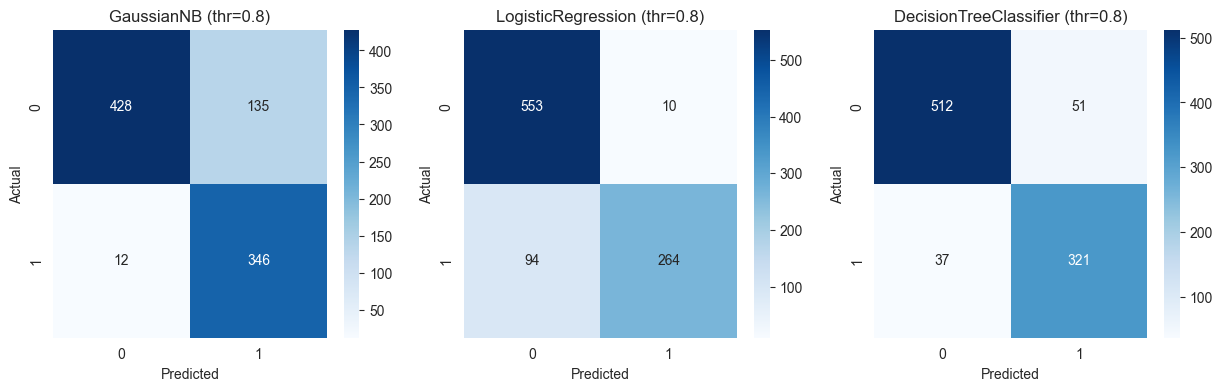

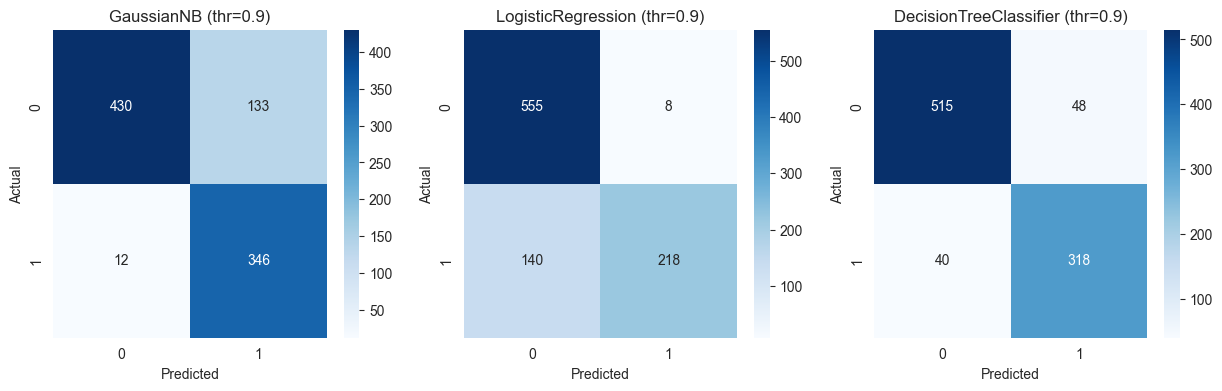

In [17]:
thresholds = [0.5, 0.6,0.7,0.8,0.9]
list_all = []
for threshold in thresholds:
    df = model_test(models, X_train, y_train, X_test, y_test, threshold=threshold)
    list_all.append(df)

df = pd.concat(list_all, ignore_index=True)
df.sort_values(by = ['misclassification_error','precision'], ascending = True, inplace = True)
df

Inspecting the results above, generally logistic regression performs the best in both minimizing the number of ham emails labeled as spam and the overall misclassification rate. At a probability threshold of 0.6, logistic regression manages to have a misclassification error of ~8% while classifying 21 ham emails as spam. This seems the best balance overall from the iterations run above.

### Optimizing Logistic Regression with Recursive Feature Elimination

Since logistic regression performed the best above, it may be worth attempting to refine it. By editing which features are being used, there is the potential for improvement overall. Below Recursive Feature Elimination is used to refine the selected features used. The reduced feature set is then used to repeat the previous analysis.

In [18]:
from sklearn.feature_selection import RFE

The following code calculates the number of features at each sample threshold. This can then be used to identify which number of features to use during the RFE to minimize the miscalculation error.

In [19]:
feat_count = len(X.columns)
df_for_feat_selec = []

for num in range(1,feat_count+1):
    for threshold in thresholds:
        selector = RFE(LogisticRegression(max_iter=10000), n_features_to_select=num)
        X_train_rfe = selector.fit_transform(X_train, y_train)
        X_test_rfe = selector.transform(X_test)
        logreg = LogisticRegression(max_iter=10000)
        log_probs = logreg.fit(X_train_rfe, y_train).predict_proba(X_test_rfe)[:,1]
        log_y_pre = (log_probs >= threshold).astype(int)
        log_accuracy = accuracy_score(y_test, log_y_pre)
        log_precision = precision_score(y_test, log_y_pre)
        log_recall = recall_score(y_test, log_y_pre)
        log_f1 = f1_score(y_test, log_y_pre)
        log_cm = confusion_matrix(y_test, log_y_pre)
        mis_error = (log_cm[0,1]+log_cm[1,0])/np.sum(log_cm)

        df_for_feat_selec.append({
            'features': num,
            'threshold': threshold,
            'accuracy': log_accuracy,
            'precision': log_precision,
            'recall': log_recall,
            'f1': log_f1,
            'tp': log_cm[0,0],
            'fp': log_cm[0,1],
            'fn': log_cm[1,0],
            'tn': log_cm[1,1],
            'mis_error': mis_error
        })

df_for_feat_selec = pd.DataFrame(df_for_feat_selec).sort_values(by = 'mis_error', ascending = True)
df_for_feat_selec

,features,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
275,56,0.5,0.938111,0.933718,0.905028,0.919149,540,23,34,324,0.061889
270,55,0.5,0.930510,0.929825,0.888268,0.908571,539,24,40,318,0.069490
280,57,0.5,0.928339,0.914773,0.899441,0.907042,533,30,36,322,0.071661
255,52,0.5,0.926167,0.926471,0.879888,0.902579,538,25,43,315,0.073833
245,50,0.5,0.926167,0.926471,0.879888,0.902579,538,25,43,315,0.073833
...,...,...,...,...,...,...,...,...,...,...,...
14,3,0.9,0.732899,0.959016,0.326816,0.487500,558,5,241,117,0.267101
2,1,0.7,0.730727,0.929688,0.332402,0.489712,554,9,239,119,0.269273
9,2,0.9,0.727470,0.949580,0.315642,0.473795,557,6,245,113,0.272530
3,1,0.8,0.699240,0.917526,0.248603,0.391209,555,8,269,89,0.300760


The analysis indicates that a probability threshold of 0.5 and using 56 features minimizes the miscalculation error. This yields the best miscalculation error at just 6.19% of emails misclassified.

The following heatmap helps visualize this:

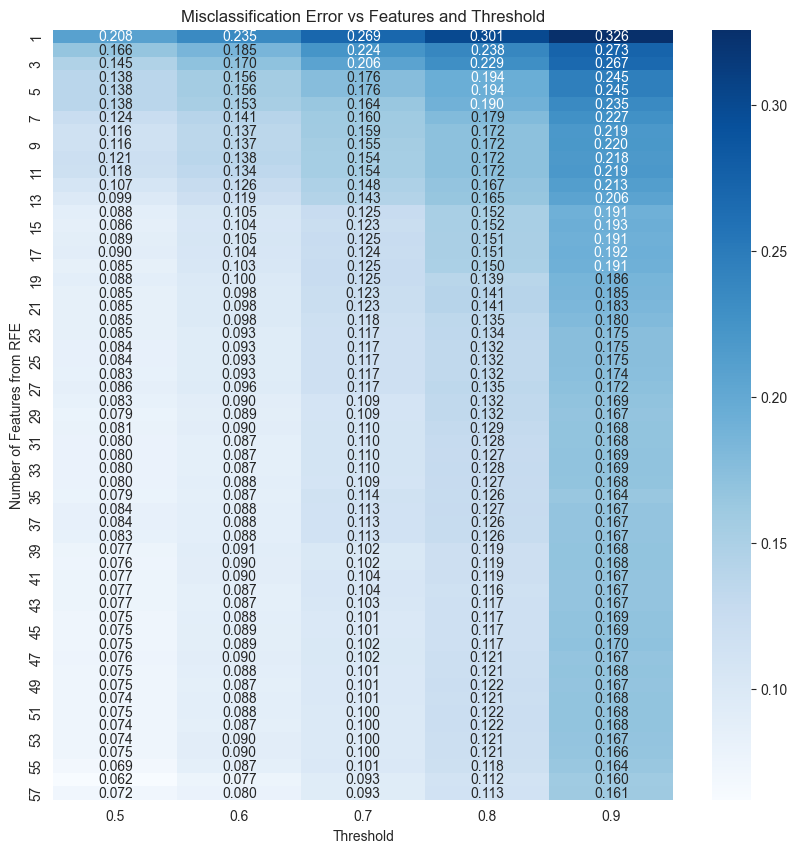

In [20]:
pivot = df_for_feat_selec.pivot(
    index = 'features',
    columns = 'threshold',
    values = 'mis_error'
)

plt.figure(figsize=(10,10))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='Blues'
)

plt.title('Misclassification Error vs Features and Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Features from RFE')
plt.show()

The other major factor to consider is minimizing false positives, or emails labeled as spam that are not. The following heatmap helps visualize how each threshold and number of features effect this number when using logisitic regression:

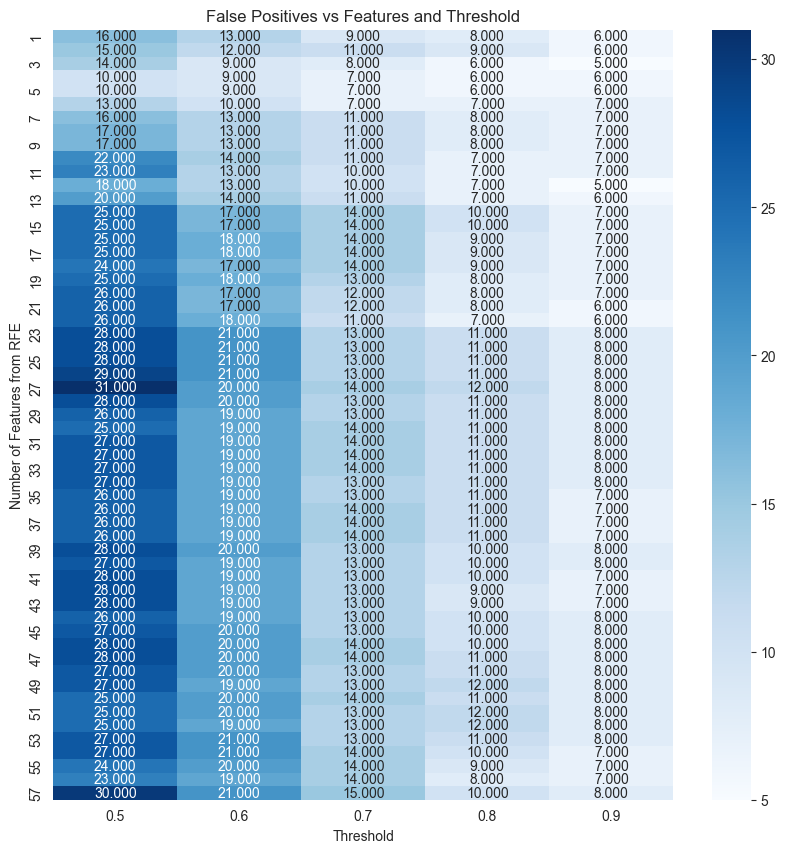

In [21]:
pivot = df_for_feat_selec.pivot(
    index = 'features',
    columns = 'threshold',
    values = 'fp'
)

plt.figure(figsize=(10,10))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='Blues'
)

plt.title('False Positives vs Features and Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Features from RFE')
plt.show()

Of course deciding threshold and feature selection exclusively by its ability to minimize false positives is not the full picture.  At the levels that minimize false positives, very few actual emails are being labeled as spam. Tuning to this parameter alone would mean a large number of emails that are spam are not being labeled as spam. See the heatmap for false negative below:

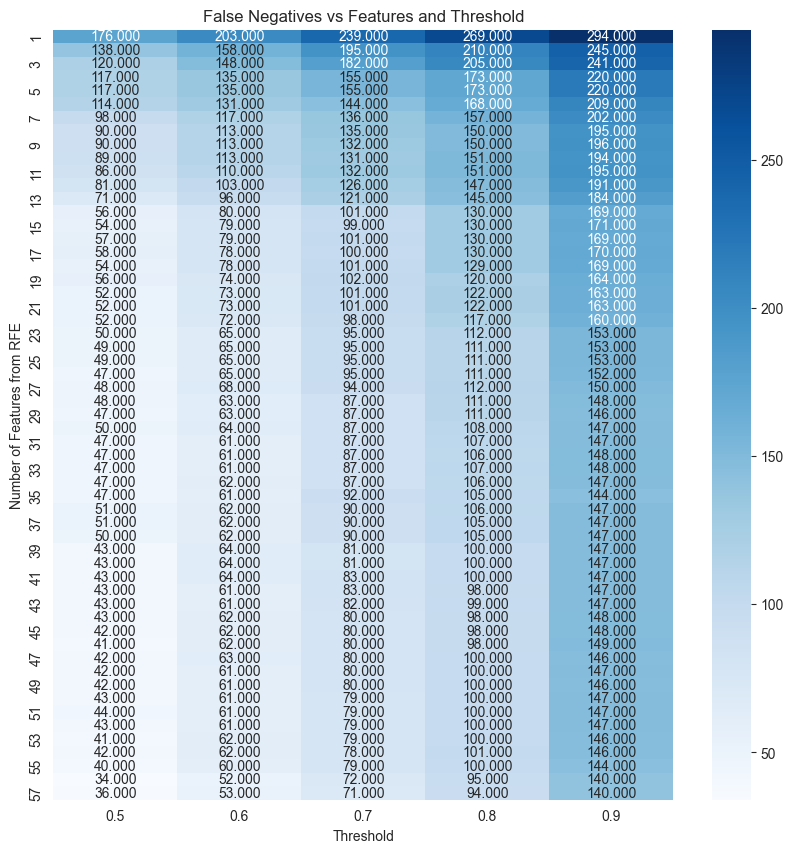

In [22]:
pivot = df_for_feat_selec.pivot(
    index = 'features',
    columns = 'threshold',
    values = 'fn'
)

plt.figure(figsize=(10,10))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='Blues'
)

plt.title('False Negatives vs Features and Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Features from RFE')
plt.show()

With the knowledge of 56 features minimizing miscalculation error when using logistic regression, let's apply that to our full analysis function and inspect the results:

In [23]:
selector = RFE(LogisticRegression(max_iter=10000), n_features_to_select=56)
X_train_rfe = selector.fit_transform(X_train, y_train)
X_test_rfe = selector.transform(X_test)

In [24]:
excluded_features = X_train.columns[~selector.support_]
print(excluded_features)

Index(['capital_run_length_total'], dtype='str')


Out of curiosity, the feature that was eliminated was the total run length of capital letters.

,model,threshold,accuracy,precision,recall,f1,misclassification_error
1,LogisticRegression,0.5,0.938111,0.933718,0.905028,0.919149,0.061889
4,LogisticRegression,0.6,0.922910,0.941538,0.854749,0.896047,0.077090
8,DecisionTreeClassifier,0.7,0.907709,0.876033,0.888268,0.882108,0.092291
14,DecisionTreeClassifier,0.9,0.907709,0.878116,0.885475,0.881780,0.092291
7,LogisticRegression,0.7,0.906623,0.953333,0.798883,0.869301,0.093377
2,DecisionTreeClassifier,0.5,0.903366,0.878873,0.871508,0.875175,0.096634
11,DecisionTreeClassifier,0.8,0.902280,0.870166,0.879888,0.875000,0.097720
5,DecisionTreeClassifier,0.6,0.900109,0.865385,0.879888,0.872576,0.099891
10,LogisticRegression,0.8,0.888165,0.970480,0.734637,0.836248,0.111835
0,GaussianNB,0.5,0.841477,0.719917,0.969274,0.826190,0.158523


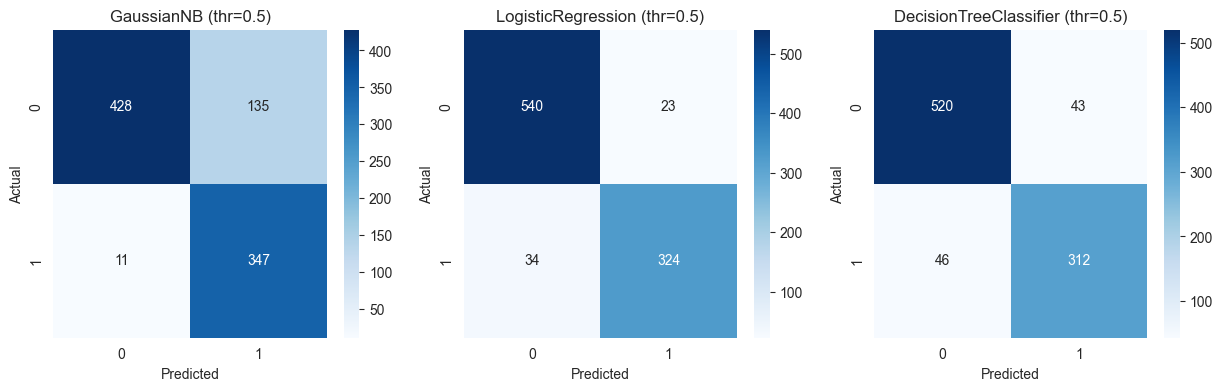

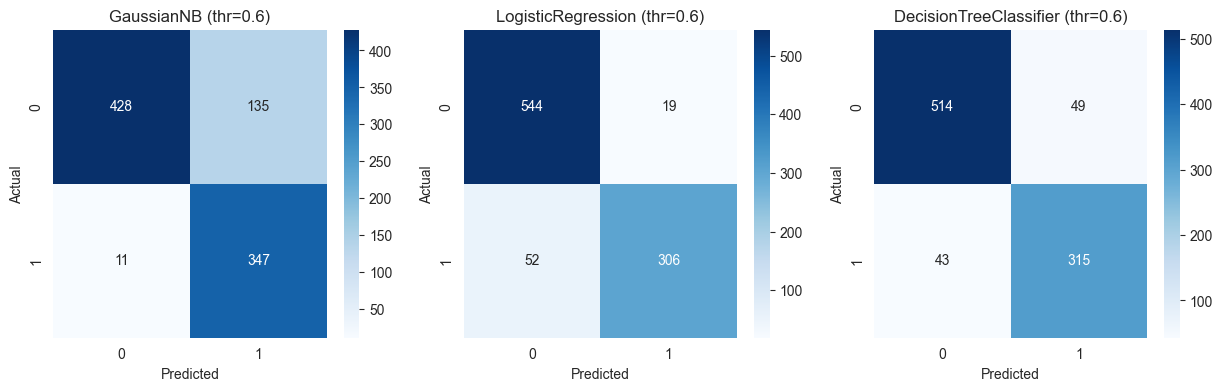

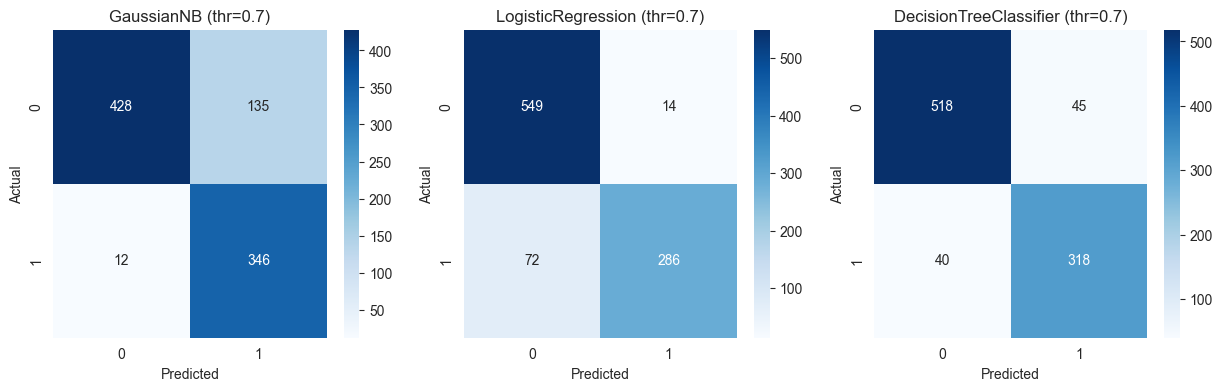

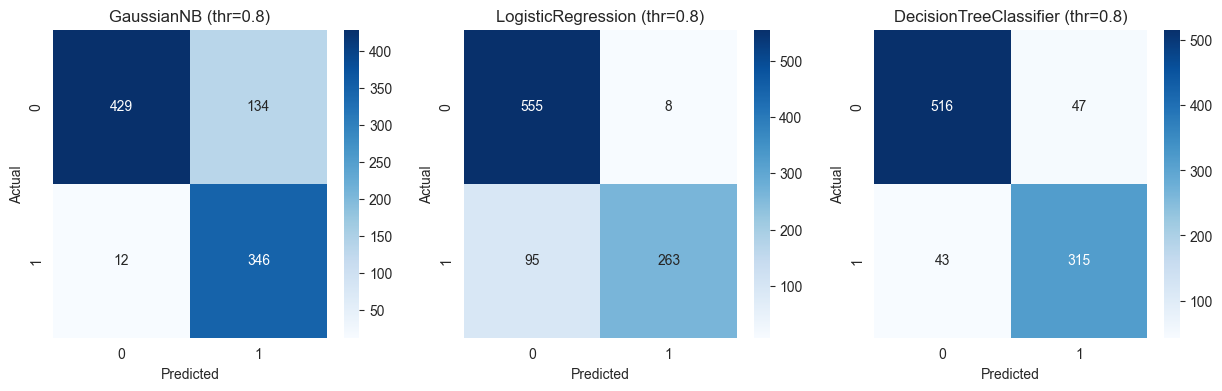

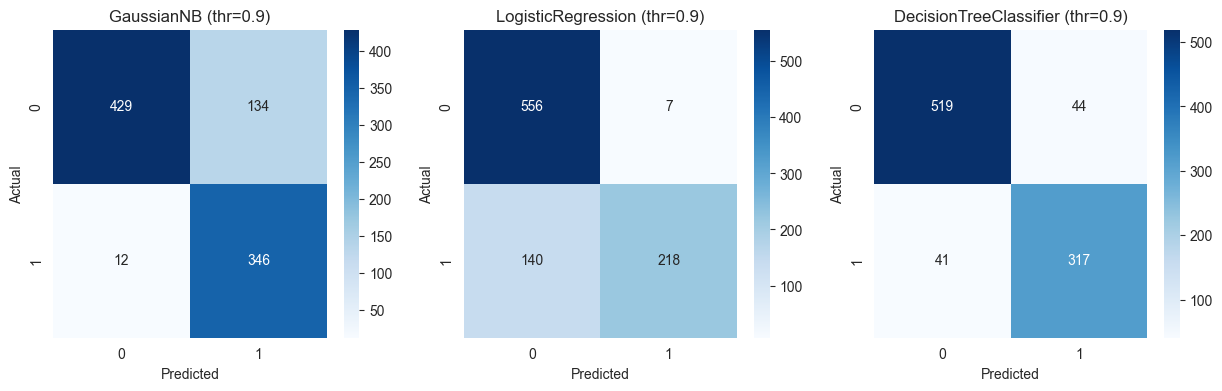

In [25]:
thresholds = [0.5, 0.6,0.7,0.8,0.9]
list_all = []
for threshold in thresholds:
    df = model_test(models, X_train_rfe, y_train, X_test_rfe, y_test, threshold=threshold)
    list_all.append(df)

df = pd.concat(list_all, ignore_index=True)
df.sort_values(by = ['misclassification_error','precision'], ascending = True, inplace = True)
df

Inspecting the results yields some interesting observations.

Generally, Naive Bayes results are relatively static at every threshold and return a fairly large number of false positives, this is not desirable.

The same is true of the Decision Tree Classifier, there is not much change in classifications, although it has a much better false positive rate in the mid to high 40s for all probability thresholds.

Logisitic Regression still performs the best according to the desired results. Depending on the tolerance for false negatives (spam making its way into the inbox) the false positives can be reduced to 7 emails at a threshold of 0.9.

That being said, the miscalculation error is minimized to only 6.19% at a probability threshold of 0.5 and 56 features.

### Tuning Decision Tree Classifier

In [26]:
tree = DecisionTreeClassifier()
tree_probs = tree.fit(X_train, y_train).predict_proba(X_test)[:,1]
tree_y_pre = (tree_probs >= 0.5).astype(int)
tree_accuracy = accuracy_score(y_test, tree_y_pre)
tree_precision = precision_score(y_test, tree_y_pre)
tree_recall = recall_score(y_test, tree_y_pre)
tree_f1 = f1_score(y_test, tree_y_pre)
tree_cm = confusion_matrix(y_test, tree_y_pre)
print(tree_accuracy)
print(tree_precision)
print(tree_recall)
print(tree_f1)
print(tree_cm)

0.9077090119435396
0.8699186991869918
0.8966480446927374
0.8830811554332875
[[515  48]
 [ 37 321]]


In [27]:
tree = DecisionTreeClassifier(max_depth=10)
tree_probs = tree.fit(X_train, y_train).predict_proba(X_test)[:,1]
tree_y_pre = (tree_probs >= 0.5).astype(int)
tree_accuracy = accuracy_score(y_test, tree_y_pre)
tree_precision = precision_score(y_test, tree_y_pre)
tree_recall = recall_score(y_test, tree_y_pre)
tree_f1 = f1_score(y_test, tree_y_pre)
tree_cm = confusion_matrix(y_test, tree_y_pre)
print(tree_accuracy)
print(tree_precision)
print(tree_recall)
print(tree_f1)
print(tree_cm)

0.9315960912052117
0.9300291545189504
0.8910614525139665
0.9101283880171184
[[539  24]
 [ 39 319]]


In [28]:
df_for_tree_params = []

for depth in range(1,20):
    for samples in range(2,20):
        for alpha in np.arange(0.0,0.011,0.001):
            for threshold in thresholds:
                    tree = DecisionTreeClassifier(max_depth=depth, min_samples_split=samples, ccp_alpha = alpha, max_features='sqrt', random_state = 1234)
                    tree_probs = tree.fit(X_train, y_train).predict_proba(X_test)[:,1]
                    tree_y_pre = (tree_probs >= threshold).astype(int)
                    tree_accuracy = accuracy_score(y_test, tree_y_pre)
                    tree_precision = precision_score(y_test, tree_y_pre, zero_division=0)
                    tree_recall = recall_score(y_test, tree_y_pre)
                    tree_f1 = f1_score(y_test, tree_y_pre)
                    tree_cm = confusion_matrix(y_test, tree_y_pre)
                    mis_error = (tree_cm[0,1]+tree_cm[1,0])/np.sum(tree_cm)

                    if tree_precision == 0.0:
                        continue
                    elif tree_precision == 1.00:
                        continue
                    else:
                        df_for_tree_params.append({
                            'max_depth': num,
                            'min_sample_split': samples,
                            'ccp_alpha': alpha,
                            'threshold': threshold,
                            'accuracy': tree_accuracy,
                            'precision': tree_precision,
                            'recall': tree_recall,
                            'f1': tree_f1,
                            'tp': tree_cm[0,0],
                            'fp': tree_cm[0,1],
                            'fn': tree_cm[1,0],
                            'tn': tree_cm[1,1],
                            'mis_error': mis_error
                        })

df_for_tree_params = pd.DataFrame(df_for_tree_params).sort_values(by = 'mis_error', ascending = True)
df_for_tree_params = df_for_tree_params[df_for_tree_params['precision'] != 0]
df_for_tree_params

,max_depth,min_sample_split,ccp_alpha,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
12162,57,8,0.001,0.7,0.922910,0.941538,0.854749,0.896047,544,19,52,306,0.077090
6977,57,3,0.001,0.7,0.920738,0.917889,0.874302,0.895565,535,28,45,313,0.079262
13355,57,12,0.001,0.7,0.920738,0.905983,0.888268,0.897038,530,33,40,318,0.079262
15491,57,15,0.000,0.6,0.920738,0.899160,0.896648,0.897902,527,36,37,321,0.079262
13356,57,12,0.001,0.8,0.920738,0.920354,0.871508,0.895265,536,27,46,312,0.079262
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11156,57,7,0.005,0.9,0.624321,0.875000,0.039106,0.074866,561,2,344,14,0.375679
16008,57,6,0.005,0.9,0.622150,0.857143,0.033520,0.064516,561,2,346,12,0.377850
16003,57,6,0.004,0.9,0.622150,0.857143,0.033520,0.064516,561,2,346,12,0.377850
16013,57,6,0.006,0.9,0.622150,0.857143,0.033520,0.064516,561,2,346,12,0.377850


When tuned, the Decision Tree approaches the Logistic Regression results. Decision tree achieves a sub 8% miscalculation error and just around 20 false positive emails with a precision in the low to mid 90%.

 ### Putting it all together

Below is running the function again, this time with the optimized parameters entered so a direct comparison is possible:

,model,threshold,accuracy,precision,recall,f1,misclassification_error
1,LogisticRegression,0.5,0.938111,0.933718,0.905028,0.919149,0.061889
4,LogisticRegression,0.6,0.922910,0.941538,0.854749,0.896047,0.077090
2,DecisionTreeClassifier,0.5,0.915309,0.874332,0.913408,0.893443,0.084691
5,DecisionTreeClassifier,0.6,0.914224,0.884298,0.896648,0.890430,0.085776
8,DecisionTreeClassifier,0.7,0.912052,0.908555,0.860335,0.883788,0.087948
7,LogisticRegression,0.7,0.906623,0.953333,0.798883,0.869301,0.093377
11,DecisionTreeClassifier,0.8,0.890337,0.924092,0.782123,0.847201,0.109663
10,LogisticRegression,0.8,0.888165,0.970480,0.734637,0.836248,0.111835
0,GaussianNB,0.5,0.841477,0.719917,0.969274,0.826190,0.158523
3,GaussianNB,0.6,0.841477,0.719917,0.969274,0.826190,0.158523


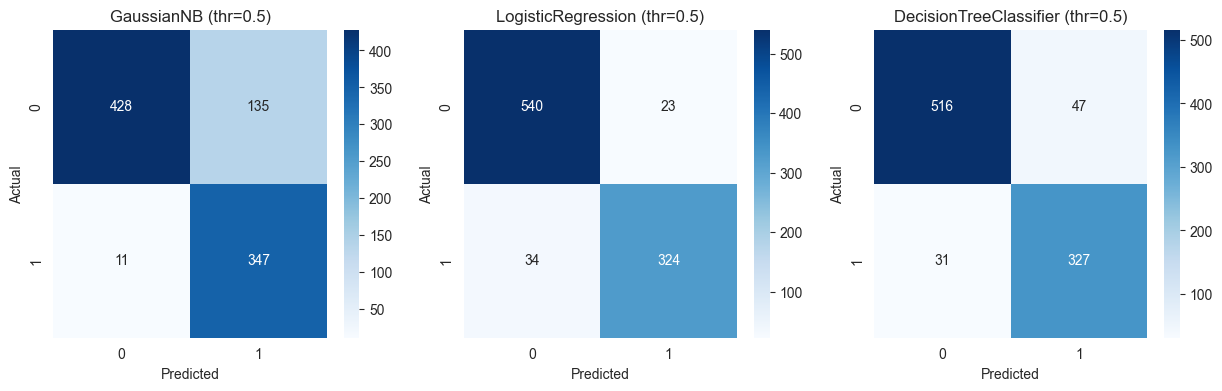

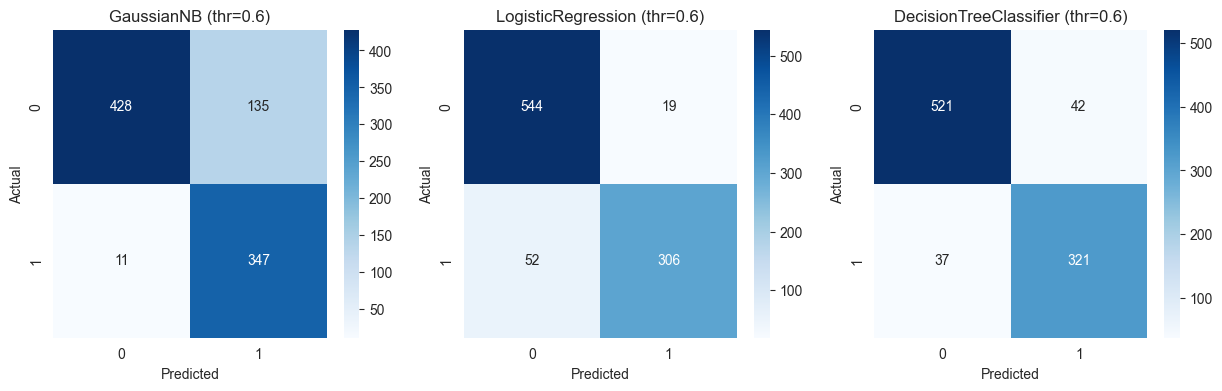

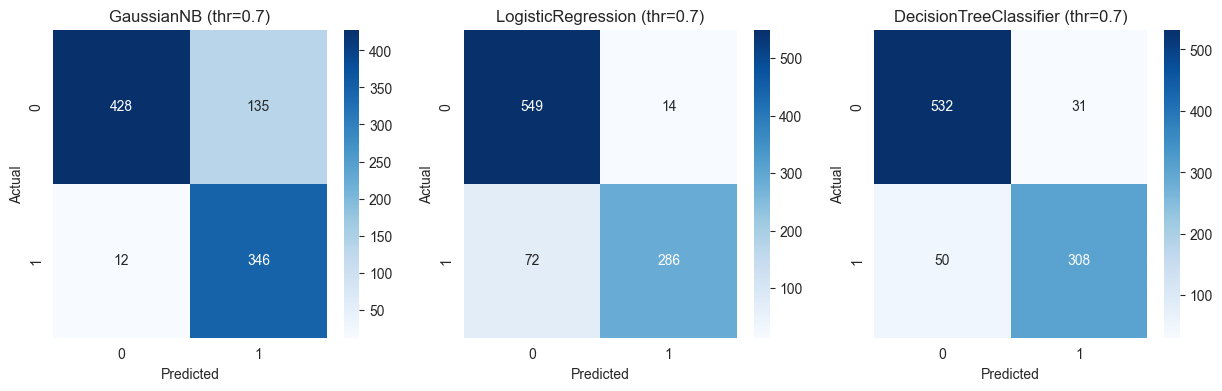

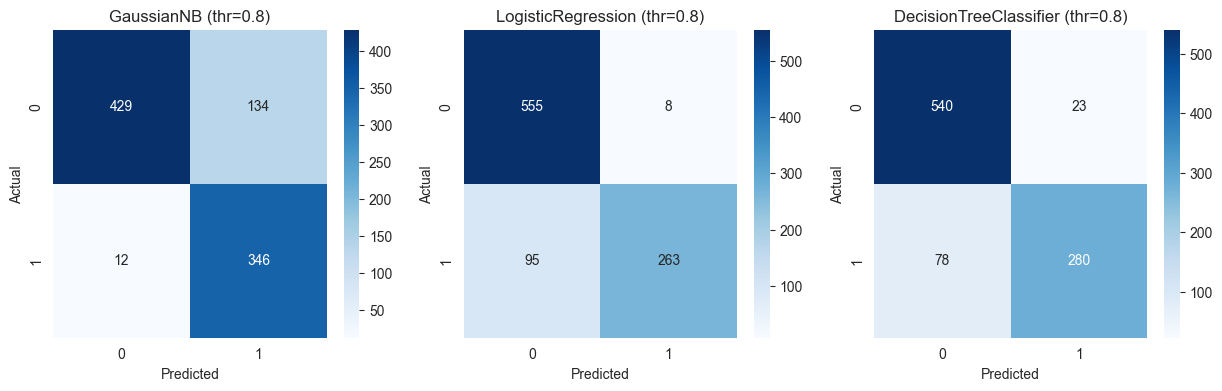

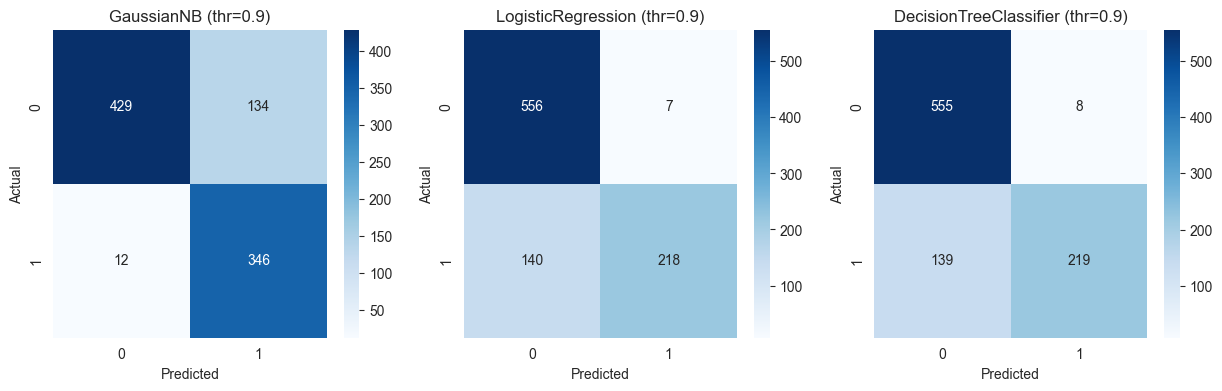

In [29]:
models_tuned = [GaussianNB(), LogisticRegression(max_iter=10000), DecisionTreeClassifier(max_depth=19, min_samples_split=3, ccp_alpha=0.002, max_features='sqrt', random_state = 1234)]

thresholds = [0.5, 0.6,0.7,0.8,0.9]
list_all = []
for threshold in thresholds:
    df = model_test(models_tuned, X_train_rfe, y_train, X_test_rfe, y_test, threshold=threshold)
    list_all.append(df)

df = pd.concat(list_all, ignore_index=True)
df.sort_values(by = ['misclassification_error'], ascending = True, inplace = True)
df

In the final models, the tradeoffs are very apparent. It is very possible to achieve a low false positive rate, as when using LogisticRegression or a DecsionTreeClassifeir at 0.9 threshold, achieving on 7 or 8 false positives, but the result is significant spam in the inbox in the neighborhood of 140 messages getting through. The ideal balance is likely using LogisticRegression at a threshold of 0.5 with the 56 features selected using RFE. This will result in a misclassification error of 6.2%, with 23 false positives, and 34 false negatives.